# Transferarbeit Data Science

**Datensatz A – E-Commerce Shipping Dataset**

Autoren: Tim Ineichen, Rodrigo Zihlmann
Modul: Data Science | Dozent: Markus Kessler | TEKO Luzern
Abgabedatum: 20.09.2026

---


## Teil 1 – Use-Case-Analyse

### 1. Datensatz-Beschreibung

Der Datensatz stammt von einem internationalen E-Commerce-Händler und enthält **10'999 Bestellungen**
mit **12 Merkmalen**. Erfasst wurden operative Bestelldaten wie das versendende Warehouse
(`Warehouse_block`), die Versandart (`Mode_of_Shipment`), die Anzahl Kundendienstanrufe
(`Customer_care_calls`), die Kundenbewertung (`Customer_rating`), der Produktpreis
(`Cost_of_the_Product`), die Anzahl früherer Käufe (`Prior_purchases`), die Produktwichtigkeit
(`Product_importance`), das Geschlecht des Kunden (`Gender`), der gewährte Rabatt
(`Discount_offered`), das Produktgewicht (`Weight_in_gms`) sowie die Zielvariable
`Reached.on.Time_Y.N`, welche angibt, ob die Lieferung pünktlich beim Kunden ankam.
Die Daten wurden vermutlich vom Logistik-/Bestellsystem des Händlers erhoben, um interne
Prozesse (Lagerwahl, Versandart, Rabattpolitik) im Hinblick auf die Liefertreue zu analysieren
und zu optimieren.

### 2. Business-Fragestellung

**Kann anhand von Bestell- und Versandmerkmalen vorhergesagt werden, ob eine Lieferung pünktlich
beim Kunden ankommt?**

### 3. Art des Problems

Es handelt sich um ein **Klassifikationsproblem** (genauer: binäre Klassifikation), da die
Zielvariable `Reached.on.Time_Y.N` nur zwei diskrete Ausprägungen annimmt (0 = pünktlich,
1 = verspätet — siehe Datenexploration unten zur exakten Kodierung). Es wird kein kontinuierlicher
Wert vorhergesagt (keine Regression) und es liegen bereits gelabelte Zielwerte vor (kein
unüberwachtes Clustering).

### 4. Mehrwert

Ein zuverlässiges Modell würde dem Unternehmen erlauben, **bereits bei Bestelleingang** zu
erkennen, welche Lieferungen mit hoher Wahrscheinlichkeit verspätet ankommen. Darauf aufbauend
könnten proaktiv Massnahmen ergriffen werden: Wahl einer schnelleren Versandart, frühzeitige
Kundenkommunikation ("Ihre Lieferung könnte sich verzögern"), Priorisierung im Warehouse oder
Anpassung der Rabattstrategie. Dies reduziert Kundenbeschwerden, erhöht die Kundenzufriedenheit
und liefert Ansatzpunkte zur Optimierung der Lieferkette.

### 5. Einschränkungen

- **Datenqualität/-herkunft:** Es ist unklar, aus welchem Zeitraum und Markt die Daten stammen;
  saisonale Effekte oder regionale Besonderheiten (z.B. Feiertage, Wetter) sind nicht abgebildet.
- **Fehlende Kontextfeatures:** Distanz zwischen Warehouse und Kunde, tatsächliches Lieferdatum
  oder externe Faktoren (Stau, Streik, Wetter) fehlen, obwohl sie die Pünktlichkeit stark
  beeinflussen dürften.
- **Kein Kausalzusammenhang:** Das Modell erkennt Korrelationen, keine Ursachen. Eine
  Fehlinterpretation (z.B. "hoher Rabatt verursacht Verspätung") könnte zu falschen
  Geschäftsentscheiden führen.
- **Ethische Aspekte:** Das Merkmal `Gender` sollte kritisch hinterfragt werden – ein
  Liefermodell sollte nicht auf Geschlecht basieren, da dies keinen plausiblen kausalen
  Zusammenhang mit der Lieferpünktlichkeit hat und zu einer nicht nachvollziehbaren
  Ungleichbehandlung führen könnte (Fairness-Aspekt).
- **Praxiseinsatz:** Fehlklassifikationen (fälschlich "pünktlich" vorhergesagte Lieferungen, die
  dann doch zu spät kommen) könnten Kundenerwartungen enttäuschen, falls sich Prozesse blind auf
  das Modell verlassen.


## Teil 2 – Datenprozessierung

**Datenquelle:** Kaggle – [E-Commerce Shipping Dataset / Customer Analytics](
https://www.kaggle.com/datasets/prachi13/customer-analytics) (`Train.csv`, ~11'000 Zeilen,
12 Spalten). Die Datei `Train.csv` liegt diesem Notebook bei bzw. muss im selben Verzeichnis
abgelegt werden.

### 2.1 Import und erster Überblick


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_theme(style="whitegrid")
PALETTE = sns.color_palette("colorblind")
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)


In [23]:
# Datensatz laden
# Quelle: Kaggle - "Customer Analytics" / E-Commerce Shipping Dataset (Train.csv)
# https://www.kaggle.com/datasets/prachi13/customer-analytics
df = pd.read_csv("Train.csv", encoding="utf-8-sig")

print("Form des Datensatzes (Zeilen, Spalten):", df.shape)
df.head()


Form des Datensatzes (Zeilen, Spalten): (10999, 12)


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [24]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


In [25]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,10999.0,NaN,NaN,NaN,5500.0,3175.28214,1.0,2750.5,5500.0,8249.5,10999.0
Warehouse_block,10999,5,F,3666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mode_of_Shipment,10999,3,Ship,7462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_care_calls,10999.0,NaN,NaN,NaN,4.054459,1.14149,2.0,3.0,4.0,5.0,7.0
Customer_rating,10999.0,NaN,NaN,NaN,2.990545,1.413603,1.0,2.0,3.0,4.0,5.0
Cost_of_the_Product,10999.0,NaN,NaN,NaN,210.196836,48.063272,96.0,169.0,214.0,251.0,310.0
Prior_purchases,10999.0,NaN,NaN,NaN,3.567597,1.52286,2.0,3.0,3.0,4.0,10.0
Product_importance,10999,3,low,5297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,10999,2,F,5545,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Discount_offered,10999.0,NaN,NaN,NaN,13.373216,16.205527,1.0,4.0,7.0,10.0,65.0


**Beobachtungen:** Der Datensatz umfasst 10'999 Bestellungen mit 12 Spalten. Es gibt 7 numerische
und 4 kategoriale Merkmale (plus die Zielvariable). `ID` ist ein reiner Zeilen-Identifikator ohne
inhaltliche Aussagekraft und wird später von den Modell-Features ausgeschlossen. Die Zielvariable
`Reached.on.Time_Y.N` ist bereits binär (0/1) kodiert.


### 2.2 Datenqualität prüfen und bereinigen

In [26]:
# Fehlende Werte pro Spalte
missing = df.isna().sum()
print("Fehlende Werte pro Spalte:")
print(missing)
print("\nAnteil fehlender Werte gesamt:", round(df.isna().mean().mean() * 100, 2), "%")


Fehlende Werte pro Spalte:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

Anteil fehlender Werte gesamt: 0.0 %


**Strategie fehlende Werte:** Der Datensatz enthält **keine fehlenden Werte** (0 NaN in allen
Spalten). Es ist daher keine Imputation oder Zeilen-/Spaltenentfernung notwendig. Dieser Schritt
wurde dennoch bewusst durchgeführt und dokumentiert, um die Datenqualität nachvollziehbar zu
bestätigen.


In [27]:
# Duplikate prüfen
n_duplicates = df.duplicated().sum()
print("Anzahl exakter Duplikate (alle Spalten identisch):", n_duplicates)

n_duplicate_ids = df["ID"].duplicated().sum()
print("Anzahl doppelter IDs:", n_duplicate_ids)


Anzahl exakter Duplikate (alle Spalten identisch): 0
Anzahl doppelter IDs: 0


**Strategie Duplikate:** Es wurden weder vollständig identische Zeilen noch doppelte
`ID`-Werte gefunden. Es müssen keine Zeilen entfernt werden.


In [28]:
# Konsistenz der kategorialen Spalten prüfen (Gross-/Kleinschreibung, Leerzeichen, Tippfehler)
cat_cols = ["Warehouse_block", "Mode_of_Shipment", "Product_importance", "Gender"]
for c in cat_cols:
    print(f"{c}: {sorted(df[c].unique())}")

# Vorsichtshalber Whitespace entfernen und Gross-/Kleinschreibung vereinheitlichen
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip()


Warehouse_block: ['A', 'B', 'C', 'D', 'F']
Mode_of_Shipment: ['Flight', 'Road', 'Ship']
Product_importance: ['high', 'low', 'medium']
Gender: ['F', 'M']


**Beobachtung:** Alle kategorialen Spalten enthalten saubere, konsistente Ausprägungen
(`Warehouse_block`: A,B,C,D,F moderiert 5 Blöcke, `Mode_of_Shipment`: Flight/Ship/Road,
`Product_importance`: low/medium/high, `Gender`: F/M). Es wurden keine Tipp- oder Zeichenfehler
gefunden; Leerzeichen wurden vorsorglich entfernt.


In [29]:
# Ausreisser-Analyse mittels IQR-Methode fuer die wichtigsten numerischen Merkmale
num_cols = ["Customer_care_calls", "Cost_of_the_Product", "Prior_purchases",
            "Discount_offered", "Weight_in_gms"]

def iqr_outlier_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return lower, upper

for c in num_cols:
    lower, upper = iqr_outlier_bounds(df[c])
    n_out = ((df[c] < lower) | (df[c] > upper)).sum()
    print(f"{c:22s}: Grenzen=[{lower:8.2f}, {upper:8.2f}]  Ausreisser={n_out:5d}  "
          f"({n_out/len(df)*100:.1f}%)")


Customer_care_calls   : Grenzen=[    0.00,     8.00]  Ausreisser=    0  (0.0%)
Cost_of_the_Product   : Grenzen=[   46.00,   374.00]  Ausreisser=    0  (0.0%)
Prior_purchases       : Grenzen=[    1.50,     5.50]  Ausreisser= 1003  (9.1%)
Discount_offered      : Grenzen=[   -5.00,    19.00]  Ausreisser= 2209  (20.1%)
Weight_in_gms         : Grenzen=[-2976.25,  9865.75]  Ausreisser=    0  (0.0%)


**Entscheidung Ausreisser:** Die IQR-Methode markiert bei `Discount_offered` und
`Prior_purchases` einen spürbaren Anteil an "Ausreissern". Bei genauerer Betrachtung handelt es
sich dabei jedoch nicht um Datenfehler, sondern um **plausible, inhaltlich bedeutsame Werte**:
hohe Rabatte werden gezielt auf schwer verkäufliche oder eilige Artikel gewährt und stehen –
wie die Explorative Datenanalyse unten zeigt – in engem Zusammenhang mit der Zielvariable.
Ein Entfernen dieser Werte würde dem Modell wichtiges Signal entziehen. Wir **behalten daher
alle Ausreisser im Datensatz** und verzichten auf ein Capping/Trimming. Bei `Weight_in_gms` und
`Cost_of_the_Product` werden praktisch keine Ausreisser erkannt, was die Datenqualität zusätzlich
bestätigt.


### 2.3 Explorative Datenanalyse (EDA)

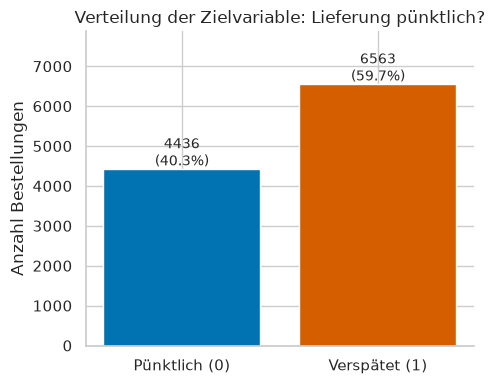

In [30]:
# 1) Verteilung der Zielvariable
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["Reached.on.Time_Y.N"].value_counts().sort_index()
labels = ["Pünktlich (0)", "Verspätet (1)"]
ax.bar(labels, counts.values, color=[PALETTE[0], PALETTE[3]])
for i, v in enumerate(counts.values):
    ax.text(i, v + 80, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=10)
ax.set_title("Verteilung der Zielvariable: Lieferung pünktlich?")
ax.set_ylabel("Anzahl Bestellungen")
ax.set_ylim(0, counts.max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()


**Interpretation:** Rund 60% der Lieferungen im Datensatz kamen **nicht** pünktlich an
(`Reached.on.Time_Y.N` = 1), nur 40% waren pünktlich. Die Klassen sind zwar nicht extrem, aber
spürbar unausgewogen (ca. 60/40). Dies wird beim Train/Test-Split (Stratifizierung) und bei der
Wahl der Metriken (nicht nur Accuracy) berücksichtigt.


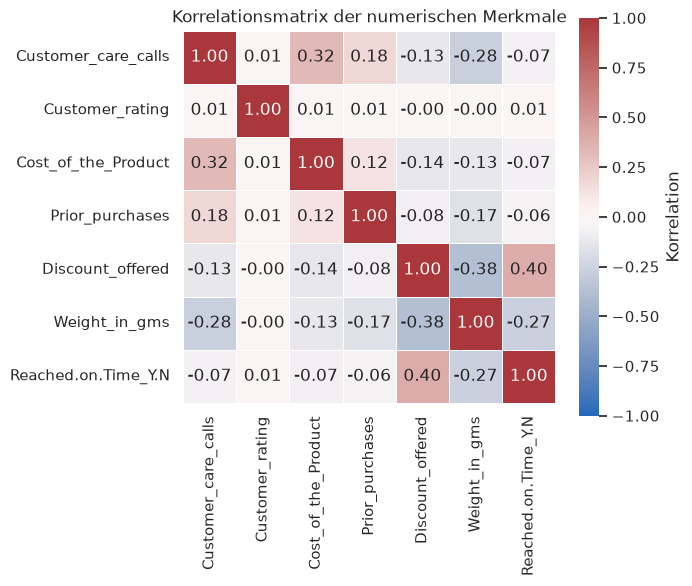

In [31]:
# 2) Korrelationen zwischen numerischen Merkmalen (inkl. Zielvariable)
corr_cols = ["Customer_care_calls", "Customer_rating", "Cost_of_the_Product",
             "Prior_purchases", "Discount_offered", "Weight_in_gms", "Reached.on.Time_Y.N"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"label": "Korrelation"})
ax.set_title("Korrelationsmatrix der numerischen Merkmale")
plt.tight_layout()
plt.show()


**Interpretation:** `Discount_offered` weist mit Abstand die stärkste (positive) Korrelation zur
Zielvariable auf: hohe Rabatte gehen mit einer höheren Wahrscheinlichkeit einer verspäteten
Lieferung einher. `Weight_in_gms` korreliert leicht negativ (schwerere Produkte kommen tendenziell
eher pünktlich an – evtl. andere Versandpriorität). Die übrigen Merkmale (`Customer_care_calls`,
`Customer_rating`, `Cost_of_the_Product`, `Prior_purchases`) zeigen nur schwache lineare
Zusammenhänge mit der Zielvariable, könnten aber dennoch in nichtlinearen Modellen (z.B. Random
Forest) an Bedeutung gewinnen.

Auch bei der korrelation zwischen den restlichen variablen ist kein stark korrelierender Wert zu finden. 
Einzig 2 leichte korrelationen sind ersichtlich zwischen `Customer_care_calls` und `Cost of the Product` sowie eine leicht negative zwischen `Discount_offered` und `Weight_in_gms`.


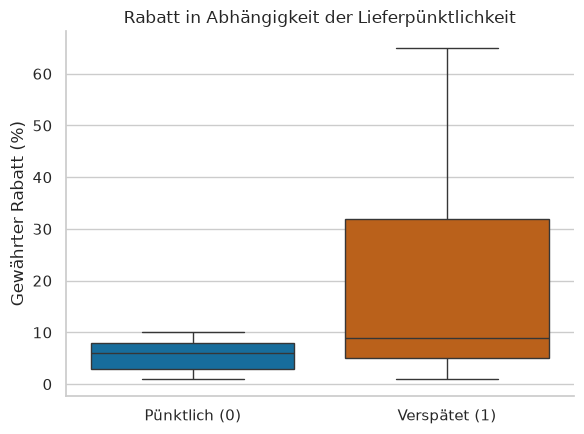

In [32]:
# 3) Discount_offered vs. Zielvariable
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=df, x="Reached.on.Time_Y.N", y="Discount_offered",
            hue="Reached.on.Time_Y.N", palette=[PALETTE[0], PALETTE[3]],
            legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Pünktlich (0)", "Verspätet (1)"])
ax.set_xlabel("")
ax.set_ylabel("Gewährter Rabatt (%)")
ax.set_title("Rabatt in Abhängigkeit der Lieferpünktlichkeit")
sns.despine()
plt.tight_layout()
plt.show()


**Interpretation:** Der Boxplot zeigt sehr deutlich: Bestellungen mit **niedrigem Rabatt**
(Median nahe 0-10%) kommen überwiegend pünktlich an, während Bestellungen mit **hohem Rabatt**
(viele Werte über 10%, teils bis über 50%) fast ausschliesslich verspätet ankommen. Dies deutet
auf ein wichtiges, nicht-triviales Muster hin: hohe Rabatte könnten mit schwer/langsamer
abzuwickelnden Bestellungen oder einer anderen internen Priorisierung zusammenhängen.


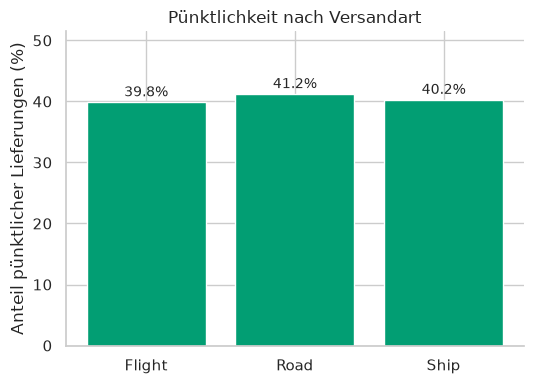

In [33]:
# 4) Anteil pünktlicher Lieferungen nach Versandart
on_time_rate = (1 - df.groupby("Mode_of_Shipment")["Reached.on.Time_Y.N"].mean()) * 100
fig, ax = plt.subplots(figsize=(5.5, 4))
bars = ax.bar(on_time_rate.index, on_time_rate.values, color=PALETTE[2])
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f"{b.get_height():.1f}%", ha="center", fontsize=10)
ax.set_ylabel("Anteil pünktlicher Lieferungen (%)")
ax.set_title("Pünktlichkeit nach Versandart")
ax.set_ylim(0, max(on_time_rate.values) * 1.25)
sns.despine()
plt.tight_layout()
plt.show()


**Interpretation:** Die Pünktlichkeitsrate unterscheidet sich zwischen den drei Versandarten
(Flight, Ship, Road) nur geringfügig. Die Versandart allein scheint somit kein starker Prädiktor
zu sein – im Gegensatz zu `Discount_offered` und `Weight_in_gms`.

**Zusammenfassung der EDA-Erkenntnisse:**
- Die Zielklassen sind mit ca. 60/40 leicht unausgewogen.
- `Discount_offered` ist das auffälligste Merkmal: hohe Rabatte korrelieren stark mit verspäteten
  Lieferungen.
- `Weight_in_gms` zeigt einen schwachen, aber erkennbaren negativen Zusammenhang mit Verspätung.
- Die Versandart (`Mode_of_Shipment`) hat kaum Einfluss auf die Pünktlichkeit.
- Kundenbezogene Merkmale (`Customer_rating`, `Gender`, `Customer_care_calls`) zeigen in der
  bivariaten Analyse keine starken linearen Zusammenhänge mit der Zielvariable.


### 2.4 Feature Engineering

In [34]:
df_fe = df.copy()

# Feature 1: Kosten pro Gramm - "Wertdichte" des Produkts.
# Begründung: Ein teures, aber leichtes Produkt könnte anders gehandhabt/versichert werden
# als ein günstiges, schweres Produkt. Das reine Verhältnis bildet dies besser ab als die
# beiden Einzelmerkmale getrennt.
df_fe["Cost_per_Gram"] = df_fe["Cost_of_the_Product"] / df_fe["Weight_in_gms"]

# Feature 2: Rabatt-Kategorie (Binning) - hoher Rabatt ist laut EDA ein starkes Signal
# für Verspätung. Eine kategoriale Schwellenwert-Variable macht dieses nichtlineare
# Muster (Sprung ab ca. 10%) explizit für einfachere Modelle wie Logistic Regression
# zugänglich, statt es implizit aus dem stetigen Wert lernen zu müssen.
df_fe["High_Discount"] = (df_fe["Discount_offered"] > 10).astype(int)

# Feature 3: Kundendienstanrufe pro bisherigem Kauf - Engagement-/Problem-Indikator.
# Begründung: Viele Anrufe bei wenigen früheren Käufen könnten auf ein aktuell
# problembehaftetes Bestellerlebnis hindeuten. +1, um Division durch 0 zu vermeiden.
df_fe["Calls_per_Prior_Purchase"] = (
    df_fe["Customer_care_calls"] / (df_fe["Prior_purchases"] + 1)
)

# Kategoriale Merkmale kodieren
# - Product_importance ist ordinal (low < medium < high) -> Ordinal-/Label-Encoding
importance_map = {"low": 0, "medium": 1, "high": 2}
df_fe["Product_importance_enc"] = df_fe["Product_importance"].map(importance_map)

# - Gender ist binär -> einfaches Label-Encoding
df_fe["Gender_enc"] = df_fe["Gender"].map({"F": 0, "M": 1})

# - Warehouse_block und Mode_of_Shipment sind nominal (keine natürliche Reihenfolge)
#   -> One-Hot-Encoding
df_fe = pd.get_dummies(df_fe, columns=["Warehouse_block", "Mode_of_Shipment"],
                        prefix=["WH", "Ship"], drop_first=False)

df_fe.head()


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Cost_per_Gram,High_Discount,Calls_per_Prior_Purchase,Product_importance_enc,Gender_enc,WH_A,WH_B,WH_C,WH_D,WH_F,Ship_Flight,Ship_Road,Ship_Ship
0,1,4,2,177,3,low,F,44,1233,1,0.143552,1,1.000000,0,0,False,False,False,True,False,True,False,False
1,2,4,5,216,2,low,M,59,3088,1,0.069948,1,1.333333,0,1,False,False,False,False,True,True,False,False
2,3,2,2,183,4,low,M,48,3374,1,0.054238,1,0.400000,0,1,True,False,False,False,False,True,False,False
3,4,3,3,176,4,medium,M,10,1177,1,0.149533,0,0.600000,1,1,False,True,False,False,False,True,False,False
4,5,2,2,184,3,medium,F,46,2484,1,0.074074,1,0.500000,1,0,False,False,True,False,False,True,False,False


**Begründung der Features:**
1. **`Cost_per_Gram`** (Verhältnis): bildet die "Wertdichte" eines Produkts ab und kombiniert
   zwei Rohmerkmale zu einer aussagekräftigeren Grösse.
2. **`High_Discount`** (Binning): macht den in der EDA gefundenen Schwellenwert-Effekt
   (Rabatt > 10% → praktisch immer verspätet) explizit als binäres Merkmal nutzbar.
3. **`Calls_per_Prior_Purchase`** (Verhältnis): ein Engagement-/Problem-Indikator, der reine
   Anrufzahlen relativ zur Kundenhistorie setzt.
4. Zusätzlich wurden alle kategorialen Merkmale kodiert: `Product_importance` ordinal (da eine
   natürliche Reihenfolge low < medium < high besteht), `Gender` binär, sowie
   `Warehouse_block`/`Mode_of_Shipment` mittels One-Hot-Encoding (keine natürliche Ordnung).


### 2.5 Train/Test-Split

In [35]:
# ID und Original-Textspalten (jetzt durch encodierte Varianten ersetzt) entfernen
drop_cols = ["ID", "Product_importance", "Gender", "Reached.on.Time_Y.N"]
X = df_fe.drop(columns=drop_cols)
y = df_fe["Reached.on.Time_Y.N"]

# 80/20-Split mit Stratifizierung, da die Zielklassen (60/40) leicht unausgewogen sind.
# Stratifizierung stellt sicher, dass Trainings- und Testset dasselbe Klassenverhältnis
# aufweisen wie der Gesamtdatensatz.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Trainingsset:", X_train.shape, " Testset:", X_test.shape)
print("Klassenverteilung Training:\n", y_train.value_counts(normalize=True).round(3))
print("Klassenverteilung Test:\n", y_test.value_counts(normalize=True).round(3))


Trainingsset: (8799, 19)  Testset: (2200, 19)
Klassenverteilung Training:
 Reached.on.Time_Y.N
1    0.597
0    0.403
Name: proportion, dtype: float64
Klassenverteilung Test:
 Reached.on.Time_Y.N
1    0.597
0    0.403
Name: proportion, dtype: float64


**Begründung:** Es wurde ein klassischer 80/20-Split gewählt – ausreichend Testdaten (ca. 2'200
Zeilen) für eine stabile Evaluation, bei gleichzeitig genügend Trainingsdaten. Die Stratifizierung
nach der Zielvariable stellt sicher, dass das leicht unausgewogene Klassenverhältnis (~60/40) in
beiden Teilmengen erhalten bleibt.


## Teil 3 – Modellwahl und Training

### 3.1 Modellwahl

Für dieses binäre Klassifikationsproblem wurden zwei unterschiedliche Modelltypen gewählt:

1. **Logistic Regression** – ein einfaches, gut interpretierbares lineares Modell, das als
   nachvollziehbare Baseline dient. Es berechnet für jede Bestellung eine Wahrscheinlichkeit
   für "verspätet", indem es eine gewichtete Summe der (skalierten) Merkmale durch die
   Sigmoid-Funktion auf einen Wert zwischen 0 und 1 abbildet.
2. **Random Forest Classifier** – ein Ensemble aus vielen Entscheidungsbäumen, die jeweils auf
   einer zufälligen Teilmenge der Daten/Merkmale trainiert werden. Die finale Vorhersage ergibt
   sich aus der Mehrheitsentscheidung aller Bäume. Random Forest kann nichtlineare
   Zusammenhänge und Wechselwirkungen zwischen Merkmalen (z.B. den in der EDA gefundenen
   Schwelleneffekt bei `Discount_offered`) besser abbilden als ein lineares Modell.

Die Kombination aus einem einfachen, interpretierbaren Modell und einem leistungsfähigeren,
nichtlinearen Modell erlaubt einen aussagekräftigen Vergleich.


### 3.2 Training

In [36]:
# Logistic Regression profitiert von skalierten Merkmalen (Gradientenbasierte Optimierung)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
print("Logistic Regression trainiert.")


Logistic Regression trainiert.


In [37]:
# Random Forest: Hyperparameter-Tuning mittels GridSearchCV (5-fach Kreuzvalidierung)
# Getestet werden die Anzahl Bäume (n_estimators) und die maximale Baumtiefe (max_depth),
# da diese den grössten Einfluss auf Bias/Varianz-Tradeoff des Random Forest haben.
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE)
grid_search = GridSearchCV(
    rf_base, param_grid, cv=5, scoring="f1", n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Beste Hyperparameter:", grid_search.best_params_)
print("Bester F1-Score (Cross-Validation):", round(grid_search.best_score_, 4))

rf_model = grid_search.best_estimator_


Beste Hyperparameter: {'max_depth': 20, 'n_estimators': 100}
Bester F1-Score (Cross-Validation): 0.6936


**Tuning-Dokumentation:** Für den Random Forest wurden `n_estimators` (100 vs. 200 Bäume) und
`max_depth` (unbegrenzt vs. 10 vs. 20) systematisch per `GridSearchCV` mit 5-facher
Kreuzvalidierung und F1-Score als Optimierungsmetrik durchsucht (F1 statt Accuracy, da die
Klassen leicht unausgewogen sind). Das beste gefundene Modell wird für die weitere Auswertung
verwendet.


### 3.3 Vorhersage

In [38]:
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

results_preview = pd.DataFrame({
    "Tatsächlich": y_test.values[:15],
    "Logistic Regression": y_pred_log[:15],
    "Random Forest": y_pred_rf[:15],
})
results_preview


,Tatsächlich,Logistic Regression,Random Forest
0,1,1,1
1,1,1,0
2,0,0,0
3,0,0,0
4,0,0,0
5,1,0,0
6,0,1,0
7,1,0,1
8,0,0,0
9,1,1,1


## Teil 4 – Auswertung, Fazit und Verbesserungsmöglichkeiten

### 4.1 Modell-Evaluation

Da es sich um ein Klassifikationsproblem mit leicht unausgewogenen Klassen handelt, werden
Accuracy, Precision, Recall, F1-Score sowie die Confusion Matrix berechnet.


In [39]:
def evaluate(y_true, y_pred, name):
    return {
        "Modell": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
    }

metrics_df = pd.DataFrame([
    evaluate(y_test, y_pred_log, "Logistic Regression"),
    evaluate(y_test, y_pred_rf, "Random Forest"),
]).set_index("Modell").round(3)

metrics_df


,Accuracy,Precision,Recall,F1-Score
Modell,,,,
Logistic Regression,0.675,0.783,0.631,0.699
Random Forest,0.662,0.768,0.621,0.687


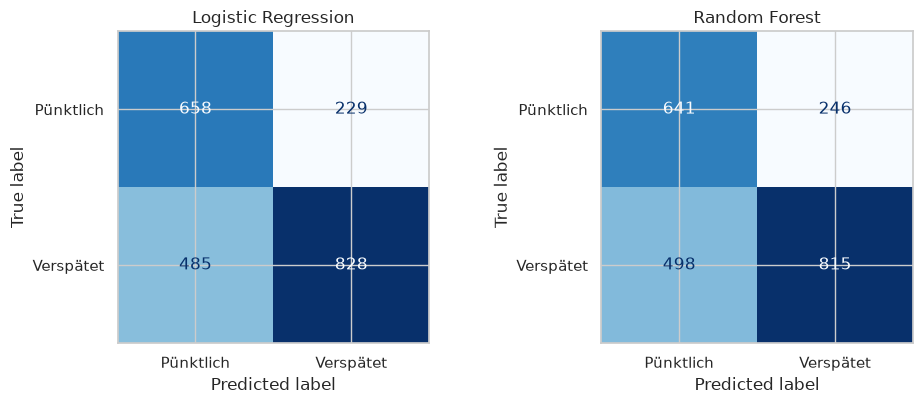

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, (name, y_pred) in zip(
    axes, [("Logistic Regression", y_pred_log), ("Random Forest", y_pred_rf)]
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Pünktlich", "Verspätet"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


**Vergleichstabelle:** siehe `metrics_df` oben. Beide Modelle werden mit denselben vier Metriken
auf dem identischen Testset verglichen.


### 4.2 Interpretation

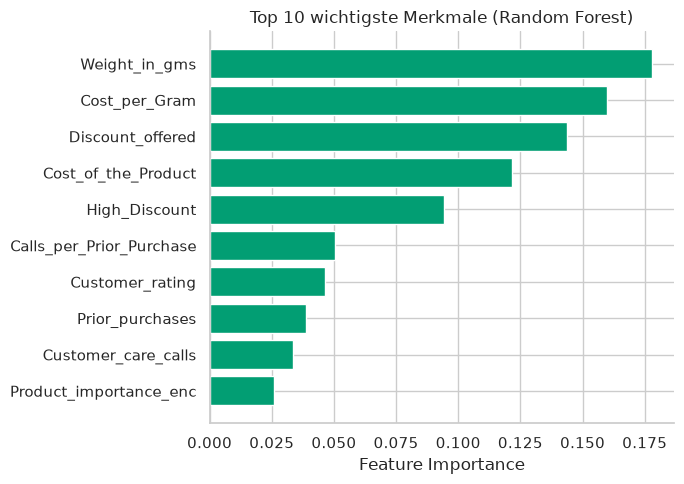

In [41]:
# Feature Importance des Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importances.index[::-1], importances.values[::-1], color=PALETTE[2])
ax.set_xlabel("Feature Importance")
ax.set_title("Top 10 wichtigste Merkmale (Random Forest)")
sns.despine()
plt.tight_layout()
plt.show()


**Interpretation der Metriken:** *(Werte gemäss obiger Tabelle `metrics_df`: Logistic Regression
Accuracy 0.675 / Precision 0.783 / Recall 0.631 / F1 0.699; Random Forest Accuracy 0.662 /
Precision 0.768 / Recall 0.621 / F1 0.687.)* **Logistic Regression** schneidet minimal besser ab als der Random Forest (F1
0.699 vs. 0.687). Eine plausible Erklärung: Der wichtigste nichtlineare Effekt im Datensatz – der
Schwellenwert bei `Discount_offered` (siehe EDA) – wurde bereits explizit als Feature
`High_Discount` kodiert und ist damit auch für ein lineares Modell direkt nutzbar. Der Random
Forest kann seinen strukturellen Vorteil (automatisches Erkennen von Nichtlinearitäten und
Interaktionen) dadurch hier weniger ausspielen, und die zusätzliche Modellkomplexität führt zu
keinem klaren Mehrwert. Beide Modelle liegen insgesamt nahe beieinander.

Für den Praxiseinsatz sind vor allem **Precision und Recall der Klasse "Verspätet"** relevant:
Die Precision (~0.77–0.78) ist deutlich höher als der Recall (~0.62–0.63) – das Modell markiert
Lieferungen also eher zurückhaltend als "verspätet", verpasst dabei aber gut ein Drittel der
tatsächlich verspäteten Lieferungen. Für ein proaktives Warnsystem wäre ein höherer Recall
wünschenswert. Mit F1-Werten um 0.69–0.70 ist das Modell als **solide Unterstützung**, aber
(noch) nicht als alleinige Entscheidungsgrundlage für kritische Geschäftsprozesse geeignet.

**Wichtigste Merkmale:** Gemäss Feature-Importance-Analyse des Random Forest sind
`Weight_in_gms`, das neu erstellte Feature `Cost_per_Gram`, `Discount_offered` und
`Cost_of_the_Product` die vier wichtigsten Prädiktoren – das ebenfalls neu erstellte
`High_Discount` folgt auf Rang 5. Dies bestätigt sowohl die Beobachtungen aus der EDA
(Teil 2.3: Rabatt und Gewicht als zentrale Treiber) als auch den Mehrwert des Feature
Engineerings aus Teil 2.4: zwei der fünf wichtigsten Merkmale wurden selbst konstruiert.


### 4.3 Fazit

Die in Teil 1 formulierte Business-Fragestellung – *"Kann anhand von Bestell- und
Versandmerkmalen vorhergesagt werden, ob eine Lieferung pünktlich beim Kunden ankommt?"* – kann
mit **Ja, mit brauchbarer Genauigkeit** beantwortet werden. Beide trainierten Modelle liefern
deutlich bessere Vorhersagen als eine zufällige Schätzung oder die blosse Mehrheitsklasse
(F1-Scores von ca. 0.69–0.70); die einfachere Logistic Regression schneidet in diesem Lauf
minimal besser ab als der Random Forest, beide Modelle liegen aber nahe beieinander. Das Ziel der
Arbeit – ein funktionierendes, evaluiertes Klassifikationsmodell für die
Liefer-Pünktlichkeitsvorhersage zu erstellen – wurde erreicht. Für einen produktiven Einsatz
wären jedoch weitere Verbesserungen (siehe 4.4) und eine sorgfältige Prüfung der ethischen
Aspekte (Teil 1, Punkt 5) notwendig.


### 4.4 Verbesserungsmöglichkeiten

1. **Mehr/bessere Daten:** Zusätzliche Merkmale wie effektive Versanddistanz, tatsächliches
   Bestell-/Lieferdatum (inkl. Wochentag, Feiertage, Saison) oder externe Faktoren (Wetter,
   Verkehr) würden die Vorhersagekraft voraussichtlich deutlich erhöhen, da der aktuelle
   Datensatz keine zeitlichen/geografischen Informationen enthält.
2. **Weitere Features:** Interaktionsterme zwischen `Discount_offered` und `Mode_of_Shipment`
   oder `Warehouse_block`, sowie eine feinere Kategorisierung/Nichtlinearisierung von
   `Discount_offered` (z.B. mittels Polynomial Features) könnten zusätzliches Signal erschliessen.
3. **Andere Modelle/Hyperparameter:** Der Einsatz von Gradient-Boosting-Verfahren wie XGBoost
   oder LightGBM, sowie eine umfangreichere Hyperparameter-Suche (z.B. `RandomizedSearchCV` über
   einen grösseren Suchraum, inkl. `min_samples_leaf`, `max_features`) könnte die Modellgüte
   weiter verbessern.
4. **Andere Vorverarbeitungsstrategien:** Techniken für unausgewogene Klassen (z.B. SMOTE,
   Class-Weighting) könnten insbesondere den Recall der Klasse "Verspätet" weiter erhöhen; zudem
   könnte eine systematische Feature-Selektion (z.B. Recursive Feature Elimination) die
   Modellkomplexität reduzieren, ohne die Performance zu verschlechtern.


---

## Hinweis zur Nutzung von KI-Tools

Für diese Arbeit wurde **Claude (Anthropic, Claude Code)** als KI-Unterstützung eingesetzt für:
- Struktur und Gerüst des Notebooks gemäss Aufgabenstellung
- Formulierungshilfe bei den Markdown-Erklärungen und der Use-Case-Analyse
- Vorschläge für Feature-Engineering-Ideen und Code-Implementierung (Datenbereinigung, EDA,
  Modelltraining, Evaluation)
- Fehlersuche/Debugging beim lauffähigen Ausführen des gesamten Notebooks

Alle Ergebnisse, Zahlen und Interpretationen wurden anhand der tatsächlichen Modell-Outputs
erstellt bzw. überprüft und nicht frei erfunden. 
